# 🛡️ CkCk Hoax Detection AI — Training Notebook

**Track B: The Privacy Brain (NLP / Generative AI)**

Fine-tuning IndoBERT-base-p2 for Indonesian hoax detection with integrated PII filtering.

---

**Dataset**: 4 source CSVs (TurnBackHoax, Antaranews, Detik, Kompas) with `judul` + `clean_text` concatenation.

## 1. Setup & Imports

In [1]:
import os
import sys
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.metrics import classification_report, confusion_matrix
import yaml

# Add project root to path
sys.path.insert(0, os.path.abspath('.'))

from src.utils import set_seed, get_device, count_parameters, load_config
from src.dataset import create_dataloaders, load_multi_csv 
from src.preprocessing import TextPreprocessor
from src.pii_filter import PIIFilter
from src.trainer import Trainer

print(f'PyTorch version: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')

PyTorch version: 2.11.0+cu130
CUDA available: True


In [2]:
# Load configuration
config = load_config('config.yaml')
set_seed(config['training']['seed'])
device = get_device()

print(f"\nModel: {config['model']['name']}")
print(f"Epochs: {config['training']['epochs']}")
print(f"Batch size: {config['training']['batch_size']}")
print(f"Learning rate: {config['training']['learning_rate']}")

[INFO] Random seed set to 42
[INFO] Using GPU: NVIDIA GeForce RTX 5070

Model: indobenchmark/indobert-base-p2
Epochs: 5
Batch size: 16
Learning rate: 2e-05


## 2. Data Exploration

In [3]:
# Load all training CSVs individually for exploration
data_cfg = config['data']
train_dir = data_cfg['train_dir']
train_files = data_cfg['train_files']

dfs = {}
for filename in train_files:
    path = os.path.join(train_dir, filename)
    df = pd.read_csv(path)
    source_name = filename.replace('Cleaned_', '').replace('.csv', '')
    dfs[source_name] = df
    print(f'{source_name}: {len(df)} rows | Labels: {df["label"].value_counts().to_dict()}')

# Combine for overall stats
combined_df = pd.concat(dfs.values(), ignore_index=True)
print(f'\n📊 Total combined: {len(combined_df)} samples')
print(f'Label distribution:\n{combined_df["label"].value_counts()}')

TurnBackHoax_v3: 12744 rows | Labels: {1: 12744}
Antaranews_v1: 4200 rows | Labels: {0: 4200}
Detik_v2: 3500 rows | Labels: {0: 3500}
Kompas_v2: 3500 rows | Labels: {0: 3500}

📊 Total combined: 23944 samples
Label distribution:
label
1    12744
0    11200
Name: count, dtype: int64


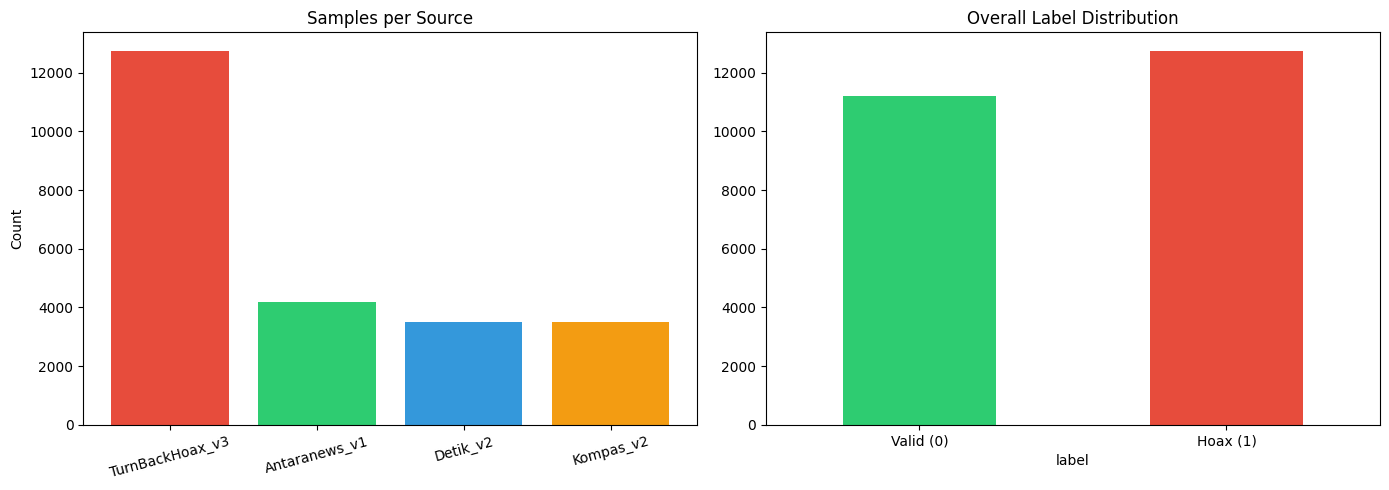

In [4]:
# Per-source breakdown chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Samples per source
source_counts = {name: len(df) for name, df in dfs.items()}
colors = ['#e74c3c', '#2ecc71', '#3498db', '#f39c12']
axes[0].bar(source_counts.keys(), source_counts.values(), color=colors)
axes[0].set_title('Samples per Source')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=15)

# Overall label distribution
combined_df['label'].value_counts().sort_index().plot(
    kind='bar', ax=axes[1], color=['#2ecc71', '#e74c3c']
)
axes[1].set_title('Overall Label Distribution')
axes[1].set_xticklabels(['Valid (0)', 'Hoax (1)'], rotation=0)

plt.tight_layout()
plt.show()

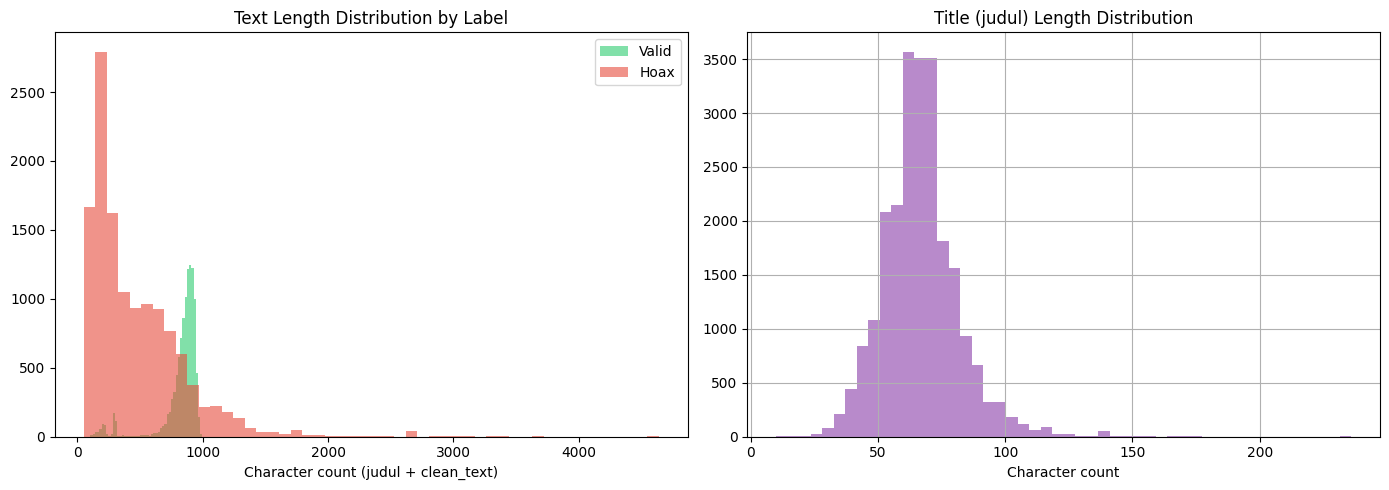

Combined text length — Mean: 629, Median: 746, Max: 4637.0


In [5]:
# Text length analysis (judul + clean_text combined)
combined_df['combined_text'] = combined_df['judul'].astype(str) + '. ' + combined_df['clean_text'].astype(str)
combined_df['text_length'] = combined_df['combined_text'].str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Text length by label
for label, color, name in [(0, '#2ecc71', 'Valid'), (1, '#e74c3c', 'Hoax')]:
    subset = combined_df[combined_df['label'] == label]
    axes[0].hist(subset['text_length'], bins=50, alpha=0.6, color=color, label=name)
axes[0].set_title('Text Length Distribution by Label')
axes[0].set_xlabel('Character count (judul + clean_text)')
axes[0].legend()

# Title length
combined_df['title_length'] = combined_df['judul'].str.len()
combined_df['title_length'].hist(bins=50, ax=axes[1], color='#9b59b6', alpha=0.7)
axes[1].set_title('Title (judul) Length Distribution')
axes[1].set_xlabel('Character count')

plt.tight_layout()
plt.show()

print(f'Combined text length — Mean: {combined_df["text_length"].mean():.0f}, '
      f'Median: {combined_df["text_length"].median():.0f}, '
      f'Max: {combined_df["text_length"].max()}')

In [6]:
# Preview samples from each source
for name, df in dfs.items():
    print(f'\n--- {name} (label={df["label"].iloc[0]}) ---')
    sample = df.iloc[0]
    print(f'  Judul: {sample["judul"][:100]}...')
    print(f'  Clean text: {sample["clean_text"][:120]}...')


--- TurnBackHoax_v3 (label=1) ---
  Judul: [SALAH] Menkeu Purbaya Curiga Permainan Bunga Rp285,6 Triliun Jadi Penyebab TPG Telat...
  Clean text: faktor pencairan tpg sering telat menkeu purbaya curiga ada permainan bunga di dana pemerintah rp 285,6 triliun yang men...

--- Antaranews_v1 (label=0) ---
  Judul: Anggota DPR minta polisi ungkap dalang perusakan Kebun Teh Pangalengan...
  Clean text: anggota komisi iv dpr ri rajiv meminta aparat kepolisian mengusut tuntas kasus perusakan kebun teh milik ptpn i regional...

--- Detik_v2 (label=0) ---
  Judul: Sekolah Lansia Ceria Bersama Hadirkan Kegiatan Produktif di Aceh Besar...
  Clean text: lansia di aceh besar mengikuti kegiatan anyaman di sekolah lansia ceria bersama, program ini mendorong lansia tetap seha...

--- Kompas_v2 (label=0) ---
  Judul: Harga Bitcoin Sentuh Titik Terendah, Diprediksi Akan Lebih Parah...
  Clean text: harga mata uang kripto (cyptocurrency) populer bitcoin (btc) turun lagi pada awal pekan ketiga november 20

## 3. PII Filter Verification

In [7]:
# Test PII Filter
pii_filter = PIIFilter()

test_texts = [
    'NIK saya 3201234506780001 tolong dijaga.',
    'Hubungi di +6281234567890 atau email budi@gmail.com',
    'Transfer ke rekening 1234567890123456',
    'Berita ini tidak mengandung data pribadi.',
]

for text in test_texts:
    result = pii_filter.filter(text)
    print(f'Input:    {result["original_text"]}')
    print(f'Filtered: {result["filtered_text"]}')
    print(f'PII found: {result["pii_count"]}')
    print()

Input:    NIK saya 3201234506780001 tolong dijaga.
Filtered: NIK saya ████████████████ tolong dijaga.
PII found: 1

Input:    Hubungi di +6281234567890 atau email budi@gmail.com
Filtered: Hubungi di █████████████0 atau email ██████████████
PII found: 2

Input:    Transfer ke rekening 1234567890123456
Filtered: Transfer ke rekening ████████████████
PII found: 1

Input:    Berita ini tidak mengandung data pribadi.
Filtered: Berita ini tidak mengandung data pribadi.
PII found: 0



## 4. Preprocessing Test

In [8]:
# Test preprocessing pipeline
preprocessor = TextPreprocessor(use_stemmer=False)

samples = [
    'BREAKING!!! Vaksin COVID berbahaya!! https://hoax.com #antivax',
    '<p>Pemerintah <b>mengumumkan</b> kebijakan baru.</p>',
    'Gak percaya gw dgn berita ini!!!',
]

for text in samples:
    cleaned = preprocessor.clean(text, normalize_slang=True)
    print(f'Original: {text}')
    print(f'Cleaned:  {cleaned}')
    print()

Original: BREAKING!!! Vaksin COVID berbahaya!! https://hoax.com #antivax
Cleaned:  breaking! vaksin covid berbahaya!

Original: <p>Pemerintah <b>mengumumkan</b> kebijakan baru.</p>
Cleaned:  pemerintah mengumumkan kebijakan baru.

Original: Gak percaya gw dgn berita ini!!!
Cleaned:  tidak percaya gw dengan berita ini!



## 5. Model Setup & Parameter Count

In [9]:
# Load model and verify parameter count (Constraint B-1)
model = AutoModelForSequenceClassification.from_pretrained(
    config['model']['name'],
    num_labels=config['model']['num_labels'],
)

total_params = count_parameters(model)
print(f'\n✅ Constraint B-1: {total_params:,} params (limit: 4,000,000,000)')
print(f'   Using {total_params/4_000_000_000*100:.2f}% of allowed budget')

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at indobenchmark/indobert-base-p2 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


[INFO] Total params: 124,442,882 | Trainable: 124,442,882

✅ Constraint B-1: 124,442,882 params (limit: 4,000,000,000)
   Using 3.11% of allowed budget


## 6. Training

In [10]:
# Initialize trainer and run training
trainer = Trainer.from_config('config.yaml')
trainer.setup()
history = trainer.train()

[INFO] Device: cuda
[INFO] Setting up training pipeline...
[INFO] Loading 4 CSV files from train_data/
[INFO] Loaded 12744 samples from Cleaned_TurnBackHoax_v3.csv
[INFO] Label distribution: {1: 12744}
[INFO] Loaded 4200 samples from Cleaned_Antaranews_v1.csv
[INFO] Label distribution: {0: 4200}
[INFO] Loaded 3267 samples from Cleaned_Detik_v2.csv
[INFO] Label distribution: {0: 3267}
[INFO] Loaded 3500 samples from Cleaned_Kompas_v2.csv
[INFO] Label distribution: {0: 3500}
[INFO] Total combined: 23711 samples
[INFO] Combined distribution: {0 (valid): 10967, 1 (hoax): 12744}
[INFO] Test set saved to test_data/test.csv (2372 samples)

[INFO] Final splits:
  Train: 18138
  Val:   3201
  Test:  2372


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at indobenchmark/indobert-base-p2 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


[INFO] Model: indobenchmark/indobert-base-p2
[INFO] Total steps: 5670, Warmup: 567
Starting Training
  Epoch 1 | Batch 10/1134 | Loss: 0.6672
  Epoch 1 | Batch 20/1134 | Loss: 0.6624
  Epoch 1 | Batch 30/1134 | Loss: 0.6939
  Epoch 1 | Batch 40/1134 | Loss: 0.5633
  Epoch 1 | Batch 50/1134 | Loss: 0.4942
  Epoch 1 | Batch 60/1134 | Loss: 0.4446
  Epoch 1 | Batch 70/1134 | Loss: 0.3581
  Epoch 1 | Batch 80/1134 | Loss: 0.2072
  Epoch 1 | Batch 90/1134 | Loss: 0.0988
  Epoch 1 | Batch 100/1134 | Loss: 0.1977
  Epoch 1 | Batch 110/1134 | Loss: 0.0350
  Epoch 1 | Batch 120/1134 | Loss: 0.0190
  Epoch 1 | Batch 130/1134 | Loss: 0.0108
  Epoch 1 | Batch 140/1134 | Loss: 0.0077
  Epoch 1 | Batch 150/1134 | Loss: 0.1322
  Epoch 1 | Batch 160/1134 | Loss: 0.0910
  Epoch 1 | Batch 170/1134 | Loss: 0.0101
  Epoch 1 | Batch 180/1134 | Loss: 0.0039
  Epoch 1 | Batch 190/1134 | Loss: 0.0026
  Epoch 1 | Batch 200/1134 | Loss: 0.0034
  Epoch 1 | Batch 210/1134 | Loss: 0.0160
  Epoch 1 | Batch 220/1134

## 7. Training Curves

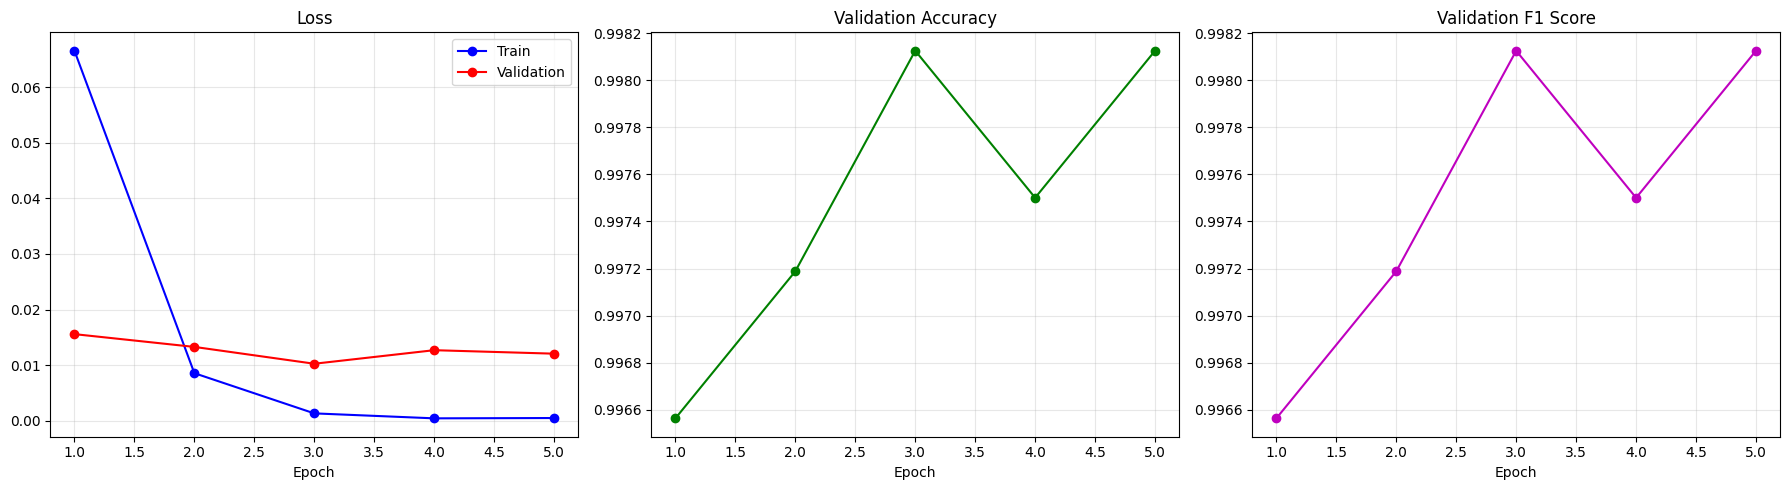

In [11]:
# Plot training curves
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

epochs = range(1, len(history['train_loss']) + 1)

# Loss
axes[0].plot(epochs, history['train_loss'], 'b-o', label='Train')
axes[0].plot(epochs, history['val_loss'], 'r-o', label='Validation')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(epochs, history['val_accuracy'], 'g-o')
axes[1].set_title('Validation Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].grid(True, alpha=0.3)

# F1 Score
axes[2].plot(epochs, history['val_f1'], 'm-o')
axes[2].set_title('Validation F1 Score')
axes[2].set_xlabel('Epoch')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Evaluation on Test Set

In [12]:
# Evaluate on test set
test_metrics = trainer.evaluate()

if test_metrics:
    print(f"\n📊 Final Test Metrics:")
    print(f"   Accuracy:  {test_metrics['accuracy']:.4f}")
    print(f"   F1 Score:  {test_metrics['f1']:.4f}")
    print(f"   Precision: {test_metrics['precision']:.4f}")
    print(f"   Recall:    {test_metrics['recall']:.4f}")


📊 Test Set Classification Report:
              precision    recall  f1-score   support

       VALID       1.00      1.00      1.00      1097
        HOAX       1.00      1.00      1.00      1275

    accuracy                           1.00      2372
   macro avg       1.00      1.00      1.00      2372
weighted avg       1.00      1.00      1.00      2372


📊 Final Test Metrics:
   Accuracy:  0.9987
   F1 Score:  0.9987
   Precision: 0.9987
   Recall:    0.9987


## 9. Save Final Model

In [13]:
# Model is automatically saved during training (best checkpoint)
# Verify saved model exists
model_path = os.path.join(config['paths']['model_dir'], 'best_model')
if os.path.exists(model_path):
    files = os.listdir(model_path)
    print(f'✅ Model saved at: {model_path}')
    print(f'   Files: {files}')
else:
    print('⚠️  No saved model found. Training may not have completed.')

⚠️  No saved model found. Training may not have completed.


---

**Training complete!** Proceed to `inference.ipynb` for the clean inference pipeline.